In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

match = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")
trends = pd.read_csv("data/gold_google_trends_daily.csv")
articles = pd.read_csv("data/gold_belga_press_articles.csv", engine="python", on_bad_lines="skip")


trends_agg = trends.groupby("match_id")["ohl_interest"].mean().reset_index()

articles_agg = articles.groupby("match_id").size().reset_index(name="num_articles")

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")
df = df.merge(trends_agg, on="match_id", how="left")
df = df.merge(articles_agg, on="match_id", how="left")

df["ohl_interest"] = df["ohl_interest"].fillna(0)
df["num_articles"] = df["num_articles"].fillna(0)


In [5]:
corr_target = df.corr(numeric_only=True)["tickets_scanned"].sort_values(ascending=False)

print(corr_target)

tickets_scanned                  1.000000
is_home_match                    0.750185
tickets_trib1                    0.713877
tickets_sold_total               0.517182
tickets_trib3                    0.499295
tickets_sold_b2c                 0.430666
pct_free_tickets                 0.354741
tickets_trib4                    0.349030
tickets_sold_b2b                 0.235197
weather_code                     0.211240
weather_windspeed_max_kmh        0.169208
num_articles                     0.128281
weekday                          0.125025
seasonpass_holders               0.108242
promo_1plus1_tickets             0.107343
weather_rain_mm                  0.102830
ohl_interest                     0.102609
weather_precipitation_mm         0.100096
weather_temp_min_c               0.059602
matchday                         0.052853
weather_temp_mean_c              0.052096
tickets_trib2_uit                0.051152
weather_temp_deviation           0.049818
is_public_holiday                0

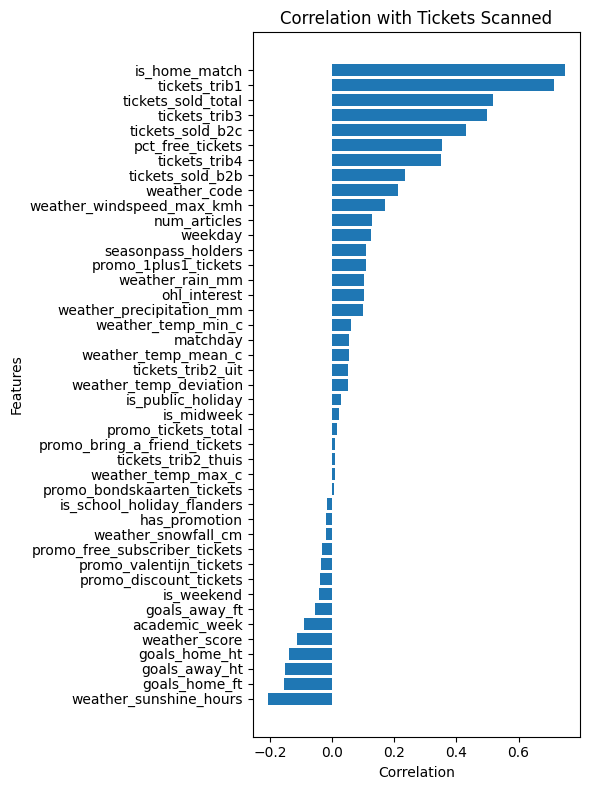

In [6]:
import matplotlib.pyplot as plt

corr_target = df.corr(numeric_only=True)["tickets_scanned"].drop("tickets_scanned").sort_values()

plt.figure(figsize=(6, 8))
plt.barh(corr_target.index, corr_target.values)
plt.title("Correlation with Tickets Scanned")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()